# EDA – Roads & Highways

Load all road/highway data from `SHP_1` into a single Polars table.

In [2]:
%pip install geopandas polars pyarrow pyogrio shapely matplotlib networkx

Note: you may need to restart the kernel to use updated packages.


In [3]:
import geopandas as gpd
import polars as pl
from pathlib import Path

SHP_DIR = Path("SHP_1")

# ── 1. Base table: catalog of roads in service ──────────────────────────
catalog = gpd.read_file(SHP_DIR / "Carreteras__Catálogo_de_carreteras_en_servicio.shp")
roads = pl.from_pandas(catalog.drop(columns="geometry"))

# ── 2. Road type (motorway, dual carriageway, conventional…) ────────────
road_type = gpd.read_file(SHP_DIR / "Carreteras__Tipo_de_vía.shp")
road_type = pl.from_pandas(road_type.drop(columns="geometry")).select(
    "Carretera", "PK_inicio", "PK_fin",
    pl.col("Tipo_de_vi").alias("Tipo_de_via"),
)

# ── 3. Environment (urban / non-urban) ──────────────────────────────────
entorno = gpd.read_file(SHP_DIR / "Carreteras__Entorno.shp")
entorno = pl.from_pandas(entorno.drop(columns="geometry")).select(
    "Carretera", "PK_inicio", "PK_fin",
    pl.col("Urbano"),
)

# ── 4. Province ─────────────────────────────────────────────────────────
provincia = gpd.read_file(SHP_DIR / "Carreteras__Provincia.shp")
provincia = pl.from_pandas(provincia.drop(columns="geometry")).select(
    "Carretera", "PK_inicio", "PK_fin",
    pl.col("Provincia"),
)

# ── 5. Ownership ────────────────────────────────────────────────────────
titularidad = gpd.read_file(SHP_DIR / "Carreteras__Titularidad.shp")
titularidad = pl.from_pandas(titularidad.drop(columns="geometry")).select(
    "Carretera", "PK_inicio", "PK_fin",
    pl.col("Titular").alias("Titularidad"),
)

# ── 6. Concession / toll roads ──────────────────────────────────────────
concesion = gpd.read_file(SHP_DIR / "Carreteras__Red_concesionada_o_con_cesión_de_gestión.shp")
concesion = pl.from_pandas(concesion.drop(columns="geometry")).select(
    "Carretera", "PK_inicio", "PK_fin",
    pl.col("Concesion"),
    pl.col("Concesiona").alias("Concesionario"),
    pl.col("Tipo_conce").alias("Tipo_concesion"),
)

# ── 7. State road network flag ──────────────────────────────────────────
rce = gpd.read_file(SHP_DIR / "Carreteras__Red_de_carreteras_del_Estado__RCE_.shp")
rce = pl.from_pandas(rce.drop(columns="geometry")).select(
    "Carretera", "PK_inicio", "PK_fin",
).with_columns(pl.lit(True).alias("Red_Estado"))

# ── 8. Join everything onto the catalog ─────────────────────────────────
join_keys = ["Carretera", "PK_inicio", "PK_fin"]

roads = (
    roads
    .join(road_type, on=join_keys, how="left")
    .join(entorno, on=join_keys, how="left")
    .join(provincia, on=join_keys, how="left")
    .join(titularidad, on=join_keys, how="left")
    .join(concesion, on=join_keys, how="left")
    .join(rce, on=join_keys, how="left")
    .with_columns(pl.col("Red_Estado").fill_null(False))
)

# ── 9. Rename columns to English ────────────────────────────────────────
roads = roads.rename({
    "Carretera": "road",
    "PK_inicio": "km_start",
    "PK_fin": "km_end",
    "Inicio": "start_location",
    "Final": "end_location",
    "Longitud": "length_m",
    "Estado": "status",
    "Valido_des": "valid_from",
    "Valido_has": "valid_until",
    "Titular": "owner",
    "TENT": "tent_network",
    "TENT_red_b": "tent_network_level",
    "TENT_corre": "tent_corridor",
    "Tipo_de_via": "road_type",
    "Urbano": "urban",
    "Provincia": "province",
    "Titularidad": "ownership",
    "Concesion": "concession",
    "Concesionario": "concessionaire",
    "Tipo_concesion": "concession_type",
    "Red_Estado": "state_network",
})

print(f"Shape: {roads.shape}")
roads.head()

c:\Pentruprogramare\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(
c:\Pentruprogramare\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(
c:\Pentruprogramare\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(
c:\Pentruprogramare\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


Shape: (1608, 21)


road,km_start,km_end,start_location,end_location,length_m,status,valid_from,valid_until,owner,tent_network,tent_network_level,tent_corridor,road_type,urban,province,ownership,concession,concessionaire,concession_type,state_network
str,f64,f64,str,str,i32,str,datetime[ms],datetime[ms],str,str,str,str,str,str,i64,str,str,str,str,bool
"""A-11""",105.4,119.3,"""Int. N-122""","""Castrillo de la Vega""",14085,"""En servicio""",2024-09-25 00:00:00,null,"""Estado""","""NO""",null,null,"""Autopista libre\Autovía""","""NO""",10,"""Estado""",null,null,null,true
"""A-11""",343.95,358.075,"""Fin N-122""","""Inicio VA-11""",14428,"""En servicio""",2024-09-25 00:00:00,null,"""Estado""","""NO""",null,null,"""Autopista libre\Autovía""","""SI""",48,"""Estado""",null,null,null,true
"""A-11""",393.9,394.12,"""Enl. A-62. Tordesillas (Oeste)""","""Enl. A-66/Int. ZA-12""",225,"""En servicio""",2024-09-25 00:00:00,null,"""Estado""","""NO""",null,null,"""Autopista libre\Autovía""","""NO""",48,"""Estado""",null,null,null,true
"""A-11""",394.12,455.82,"""Enl. A-62. Tordesillas (Oeste)""","""Enl. A-66/Int. ZA-12""",61402,"""En servicio""",2024-09-25 00:00:00,null,"""Estado""","""SI""","""Comprehensive""",null,"""Autopista libre\Autovía""","""NO""",null,"""Estado""",null,null,null,true
"""A-11""",461.0,466.8,"""Enl. A-66""","""Int. N-122""",7083,"""En servicio""",2024-09-25 00:00:00,null,"""Estado""","""SI""","""Comprehensive""",null,"""Autopista libre\Autovía""","""NO""",50,"""Estado""",null,null,null,true


In [ ]:
roads.

Check the dimensions of the merged roads dataset — 1,608 road segments across 21 attributes.

In [4]:
roads.shape

(1608, 21)

In [5]:
roads.columns

['road',
 'km_start',
 'km_end',
 'start_location',
 'end_location',
 'length_m',
 'status',
 'valid_from',
 'valid_until',
 'owner',
 'tent_network',
 'tent_network_level',
 'tent_corridor',
 'road_type',
 'urban',
 'province',
 'ownership',
 'concession',
 'concessionaire',
 'concession_type',
 'state_network']

### Road Network Map by Type
Map of all roads in Spain's national road network, color-coded by type: conventional roads, motorways/dual carriageways, multi-lane roads, and toll motorways.

c:\Pentruprogramare\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


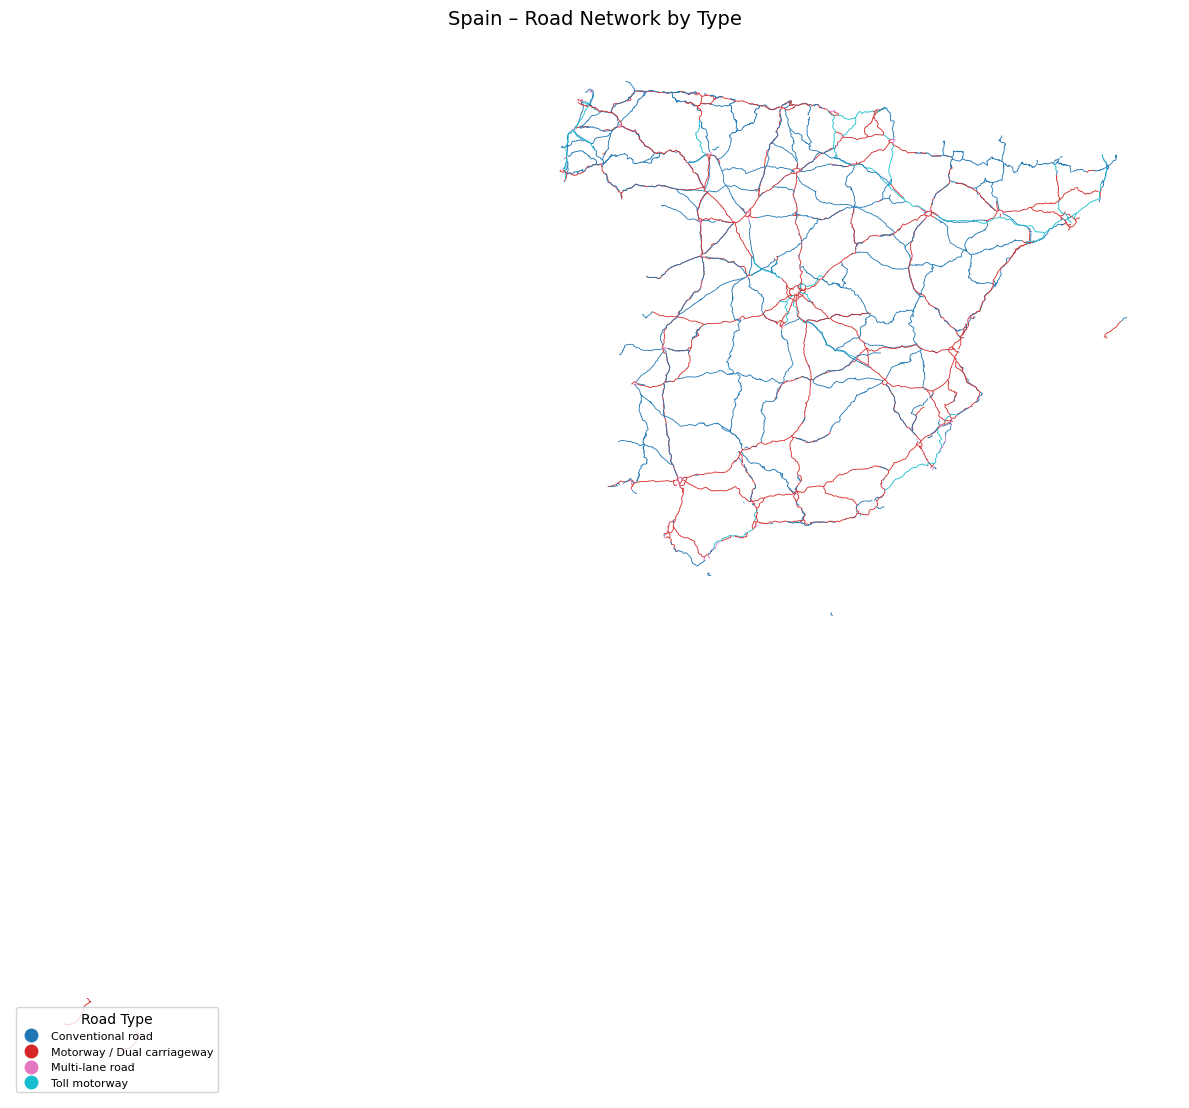

In [6]:
import matplotlib.pyplot as plt

# Load road type shapefile (has geometry + road type)
roads_geo = gpd.read_file(SHP_DIR / "Carreteras__Tipo_de_vía.shp")

# Translate road types to English
road_type_map = {
    "Carretera convencional": "Conventional road",
    "Autopista libre\\Autovía": "Motorway / Dual carriageway",
    "Multicarril": "Multi-lane road",
    "Autopista peaje": "Toll motorway",
}
roads_geo["road_type"] = roads_geo["Tipo_de_vi"].map(road_type_map)

fig, ax = plt.subplots(figsize=(12, 14))
roads_geo.plot(
    column="road_type",
    ax=ax,
    legend=True,
    linewidth=0.6,
    legend_kwds={"title": "Road Type", "fontsize": 8, "loc": "lower left"},
)
ax.set_title("Spain – Road Network by Type", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Province Connectivity Graph
Graph representation of Spain's road network where each node is a provincial capital and edges represent roads connecting neighboring provinces. Thicker edges indicate more roads between two provinces.

c:\Pentruprogramare\Lib\site-packages\pyogrio\raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D LineString' is converted to 'LineString Z'
  return ogr_read(


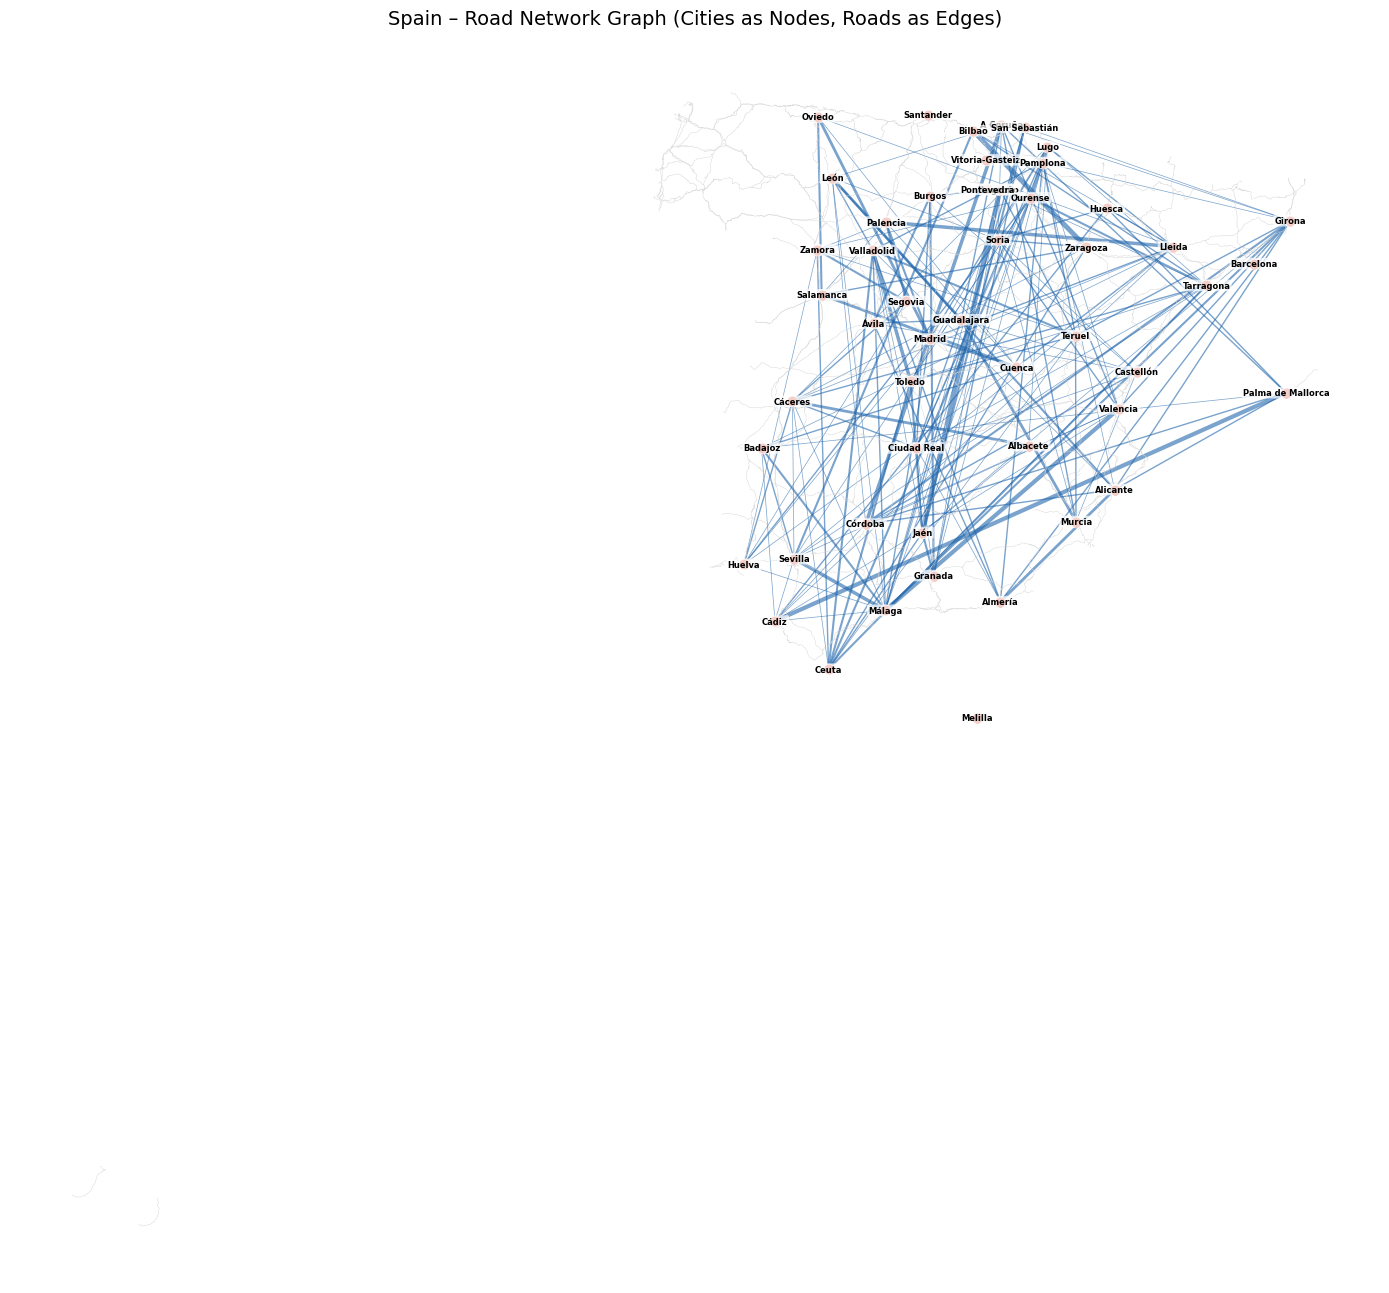

Nodes (cities): 50
Edges (road connections): 161


In [7]:
import networkx as nx
import numpy as np

# ── Spanish province codes (INE) → capital city names & coordinates (EPSG:25830) ──
# Coordinates are approximate UTM zone 30N for each provincial capital
PROVINCE_CAPITALS = {
    1: ("Vitoria-Gasteiz", 525800, 4745300),
    2: ("Albacete", 589800, 4313800),
    3: ("Alicante", 719700, 4247400),
    4: ("Almería", 547200, 4078200),
    5: ("Ávila", 355600, 4498600),
    6: ("Badajoz", 186500, 4310200),
    7: ("Palma de Mallorca", 978700, 4393600),
    8: ("Barcelona", 930600, 4588600),
    9: ("Burgos", 441200, 4690700),
    10: ("Cáceres", 233200, 4380800),
    11: ("Cádiz", 206700, 4048800),
    12: ("Castellón", 752800, 4425200),
    13: ("Ciudad Real", 420500, 4310300),
    14: ("Córdoba", 343800, 4195500),
    15: ("A Coruña", 548800, 4798300),
    16: ("Cuenca", 571500, 4432400),
    17: ("Girona", 985200, 4653300),
    18: ("Granada", 446500, 4117500),
    19: ("Guadalajara", 488200, 4503800),
    20: ("San Sebastián", 583700, 4794400),
    21: ("Huelva", 160000, 4134600),
    22: ("Huesca", 707800, 4672500),
    23: ("Jaén", 429500, 4182300),
    24: ("León", 293200, 4718000),
    25: ("Lleida", 808200, 4614200),
    26: ("Logroño", 546700, 4700200),
    27: ("Lugo", 618300, 4765400),
    28: ("Madrid", 440500, 4474800),
    29: ("Málaga", 373400, 4065100),
    30: ("Murcia", 661400, 4199100),
    31: ("Pamplona", 611200, 4741300),
    32: ("Ourense", 592700, 4688200),
    33: ("Oviedo", 271700, 4810300),
    34: ("Palencia", 374200, 4651400),
    35: ("Las Palmas", None, None),
    36: ("Pontevedra", 527700, 4701000),
    37: ("Salamanca", 277300, 4541600),
    38: ("Santa Cruz de Tenerife", None, None),
    39: ("Santander", 437800, 4813500),
    40: ("Segovia", 405300, 4531400),
    41: ("Sevilla", 235500, 4143100),
    42: ("Soria", 543800, 4624600),
    43: ("Tarragona", 858400, 4555600),
    44: ("Teruel", 660700, 4479800),
    45: ("Toledo", 411600, 4411100),
    46: ("Valencia", 725800, 4369200),
    47: ("Valladolid", 354700, 4608600),
    48: ("Bilbao", 505800, 4789200),
    49: ("Zamora", 270600, 4609300),
    50: ("Zaragoza", 676800, 4613600),
    51: ("Ceuta", 287700, 3976200),
    52: ("Melilla", 511500, 3903100),
}

# ── Build graph: cities as nodes, roads as edges ────────────────────────
# Load province-level road data (each segment tagged with a province)
prov_geo = gpd.read_file(SHP_DIR / "Carreteras__Provincia.shp")

# For each road, find which provinces it passes through → edges between them
G = nx.Graph()

# Add city nodes (skip islands with no UTM coords)
for code, (name, x, y) in PROVINCE_CAPITALS.items():
    if x is not None:
        G.add_node(name, pos=(x, y))

# Group by road name: provinces connected by the same road form edges
for road_name, group in prov_geo.groupby("Carretera"):
    provinces = sorted(group["Provincia"].unique())
    for i in range(len(provinces) - 1):
        p1, p2 = provinces[i], provinces[i + 1]
        if p1 in PROVINCE_CAPITALS and p2 in PROVINCE_CAPITALS:
            c1 = PROVINCE_CAPITALS[p1][0]
            c2 = PROVINCE_CAPITALS[p2][0]
            if PROVINCE_CAPITALS[p1][1] is not None and PROVINCE_CAPITALS[p2][1] is not None:
                # Sum road length between these provinces
                seg_len = group[group["Provincia"].isin([p1, p2])]["Longitud"].sum()
                if G.has_edge(c1, c2):
                    G[c1][c2]["roads"].append(road_name)
                else:
                    G.add_edge(c1, c2, roads=[road_name], length=seg_len)

# ── Plot the graph over road geometry ───────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 16))

# Draw roads in light gray as background
roads_geo.plot(ax=ax, color="lightgray", linewidth=0.3)

# Draw graph
pos = nx.get_node_attributes(G, "pos")
edges = G.edges()
edge_widths = [min(len(G[u][v]["roads"]), 8) * 0.5 for u, v in edges]

nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#2166ac", width=edge_widths, alpha=0.6)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=60, node_color="#d6604d", edgecolors="white", linewidths=0.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=6, font_weight="bold",
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

ax.set_title("Spain – Road Network Graph (Cities as Nodes, Roads as Edges)", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

print(f"Nodes (cities): {G.number_of_nodes()}")
print(f"Edges (road connections): {G.number_of_edges()}")

In [8]:
G.nodes()

NodeView(('Vitoria-Gasteiz', 'Albacete', 'Alicante', 'Almería', 'Ávila', 'Badajoz', 'Palma de Mallorca', 'Barcelona', 'Burgos', 'Cáceres', 'Cádiz', 'Castellón', 'Ciudad Real', 'Córdoba', 'A Coruña', 'Cuenca', 'Girona', 'Granada', 'Guadalajara', 'San Sebastián', 'Huelva', 'Huesca', 'Jaén', 'León', 'Lleida', 'Logroño', 'Lugo', 'Madrid', 'Málaga', 'Murcia', 'Pamplona', 'Ourense', 'Oviedo', 'Palencia', 'Pontevedra', 'Salamanca', 'Santander', 'Segovia', 'Sevilla', 'Soria', 'Tarragona', 'Teruel', 'Toledo', 'Valencia', 'Valladolid', 'Bilbao', 'Zamora', 'Zaragoza', 'Ceuta', 'Melilla'))

Node degree for each city — i.e., how many other provinces each capital is directly connected to by road.

In [9]:
orase=dict(G.degree())

orase

{'Vitoria-Gasteiz': 0,
 'Albacete': 3,
 'Alicante': 7,
 'Almería': 6,
 'Ávila': 4,
 'Badajoz': 6,
 'Palma de Mallorca': 6,
 'Barcelona': 0,
 'Burgos': 5,
 'Cáceres': 11,
 'Cádiz': 8,
 'Castellón': 7,
 'Ciudad Real': 11,
 'Córdoba': 8,
 'A Coruña': 8,
 'Cuenca': 7,
 'Girona': 10,
 'Granada': 6,
 'Guadalajara': 6,
 'San Sebastián': 4,
 'Huelva': 7,
 'Huesca': 4,
 'Jaén': 10,
 'León': 7,
 'Lleida': 11,
 'Logroño': 6,
 'Lugo': 8,
 'Madrid': 7,
 'Málaga': 15,
 'Murcia': 5,
 'Pamplona': 8,
 'Ourense': 9,
 'Oviedo': 4,
 'Palencia': 6,
 'Pontevedra': 0,
 'Salamanca': 4,
 'Santander': 0,
 'Segovia': 4,
 'Sevilla': 9,
 'Soria': 8,
 'Tarragona': 10,
 'Teruel': 8,
 'Toledo': 7,
 'Valencia': 8,
 'Valladolid': 10,
 'Bilbao': 4,
 'Zamora': 6,
 'Zaragoza': 5,
 'Ceuta': 9,
 'Melilla': 0}

Check Madrid's connectivity specifically.

In [22]:
MAdrid={k:v for k,v in orase.items() if k == "Madrid"}
MAdrid

{'Madrid': 7}

Filter for cities with 5 or more road connections — the most well-connected provinces.

In [20]:
high_roads={k:v for k,v in orase.items() if v >= 5
        }
high_roads

{'Alicante': 7,
 'Almería': 6,
 'Badajoz': 6,
 'Palma de Mallorca': 6,
 'Burgos': 5,
 'Cáceres': 11,
 'Cádiz': 8,
 'Castellón': 7,
 'Ciudad Real': 11,
 'Córdoba': 8,
 'A Coruña': 8,
 'Cuenca': 7,
 'Girona': 10,
 'Granada': 6,
 'Guadalajara': 6,
 'Huelva': 7,
 'Jaén': 10,
 'León': 7,
 'Lleida': 11,
 'Logroño': 6,
 'Lugo': 8,
 'Madrid': 7,
 'Málaga': 15,
 'Murcia': 5,
 'Pamplona': 8,
 'Ourense': 9,
 'Palencia': 6,
 'Sevilla': 9,
 'Soria': 8,
 'Tarragona': 10,
 'Teruel': 8,
 'Toledo': 7,
 'Valencia': 8,
 'Valladolid': 10,
 'Zamora': 6,
 'Zaragoza': 5,
 'Ceuta': 9}

The road infrastructure is based on a demand structure ( the more people want to get to a place the more likely that place has more roads). The most sought after cities in the database are "Caceres, Ciudad Real, Lleida and Malaga". AKA great places to have hubs at.

### Enriching the Dataset
For each road, collect the list of provincial capitals it passes through and join this back onto the main table.

In [11]:
from collections import defaultdict                                                                                                                                                                                                                                                   
road_cities = defaultdict(set)                                                                                                            
for u, v, data in G.edges(data=True):
    for road_name in data["roads"]:
        road_cities[road_name].add(u)
        road_cities[road_name].add(v)

cities_df = pl.DataFrame({
      "road": list(road_cities.keys()),
      "cities": [", ".join(sorted(cities)) for cities in road_cities.values()]
  })

roads = roads.join(cities_df, on="road", how="left")


### Longest Road Segments
Compute segment length in km and find the top 5 longest segments along with the cities they connect.

In [12]:
roads_length=roads.with_columns(
    (pl.col("km_end")-pl.col("km_start")).alias("km_length")
    )
top_5_longest_roads=roads_length.select(pl.col("cities"),pl.col("km_length")).sort("km_length",descending=True).limit(5)

In [13]:
pl.Config.set_fmt_str_lengths(200)
top_5_longest_roads.select(pl.col("cities"))

cities
str
"""A Coruña, Guadalajara, León, Palma de Mallorca"""
"""A Coruña, Badajoz, Cádiz, Córdoba, Palma de Mallorca, Valencia"""
"""Alicante, Córdoba, Palma de Mallorca"""
"""Huesca, Palma de Mallorca"""
"""Almería, Burgos, Ciudad Real, Granada, Pamplona, Teruel, Valladolid, Ávila"""
